In [1]:
import OnlineDB as odb
import sqlite3 as sq3
import pandas as pd
import QueryData as qd
import VizData as vz


In [2]:
%pwd

'/Users/sajiniudawela/OnlineSales'

In [3]:
location_path = "/Users/sajiniudawela/Desktop/OnlineSales"
db_name = "OnlineDB"

conn = odb.create_sqlite_connection(location_path, db_name)


Database created successfully at /Users/sajiniudawela/Desktop/OnlineSalesOnlineDB


In [4]:
odb.create_tables(conn)

Tables created successfully


In [5]:
loca = '/Users/sajiniudawela/Desktop/OnlineSales'
filename = 'customers.csv'
cust_df = odb.dataframe(loca, filename)
cust_df.head()  

,CustomerID,Country
0,13085.0,United Kingdom
1,13078.0,United Kingdom
2,15362.0,United Kingdom
3,18102.0,United Kingdom
4,12682.0,France


In [6]:
customers_df = odb.clean_df(cust_df)
customers_df.head

<bound method NDFrame.head of       CustomerID         Country
0        13085.0  United Kingdom
1        13078.0  United Kingdom
2        15362.0  United Kingdom
3        18102.0  United Kingdom
4        12682.0          France
...          ...             ...
4396     18269.0  United Kingdom
4397     13270.0  United Kingdom
4398     12942.0  United Kingdom
4399     13369.0  United Kingdom
4400     15211.0  United Kingdom

[4388 rows x 2 columns]>

In [7]:
conn = sq3.connect('OnlineDB.db')  
odb.inserting_df__db(cust_df, 'Customers', conn)

Customers table populated successfully.


In [8]:
loca = '/Users/sajiniudawela/Desktop/OnlineSales'
filename = 'products.csv'
products_df = odb.dataframe(loca, filename)
products_df.head()  

,StockCode,Description,UnitPrice
0,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,6.95
1,79323P,PINK CHERRY LIGHTS,6.75
2,79323W,WHITE CHERRY LIGHTS,6.75
3,22041,"RECORD FRAME 7"" SINGLE SIZE",2.10
4,21232,STRAWBERRY CERAMIC TRINKET BOX,1.25


In [9]:
products_df = odb.clean_df(products_df)
products_df.head

<bound method NDFrame.head of       StockCode                          Description  UnitPrice
0         85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS       6.95
1        79323P                   PINK CHERRY LIGHTS       6.75
2        79323W                  WHITE CHERRY LIGHTS       6.75
3         22041         RECORD FRAME 7" SINGLE SIZE        2.10
4         21232       STRAWBERRY CERAMIC TRINKET BOX       1.25
...         ...                                  ...        ...
19022       DOT                       DOTCOM POSTAGE     822.94
19023     22838        3 TIER CAKE TIN RED AND CREAM      29.95
19024       DOT                       DOTCOM POSTAGE      85.79
19028    46000S                         Dotcom sales       0.00
19029    46000M                         Dotcom sales       0.00

[17110 rows x 3 columns]>

In [10]:
conn = sq3.connect('OnlineDB.db') 
odb.inserting_df__db(products_df, 'Products', conn)


Products table populated successfully.


In [11]:
loca = '/Users/sajiniudawela/Desktop/OnlineSales'
filename = 'transactions.csv'
transactions_df = odb.dataframe(loca, filename)
transactions_df.head()  

,InvoiceNo,CustomerID,StockCode,Quantity,InvoiceDate,UnitPrice,TotalAmount_GBP
0,489434,13085.0,85048,12,2009-12-01 07:45:00,6.95,83.4
1,489434,13085.0,79323P,12,2009-12-01 07:45:00,6.75,81.0
2,489434,13085.0,79323W,12,2009-12-01 07:45:00,6.75,81.0
3,489434,13085.0,22041,48,2009-12-01 07:45:00,2.10,100.8
4,489434,13085.0,21232,24,2009-12-01 07:45:00,1.25,30.0


In [12]:
transactions_df = odb.clean_df(transactions_df)
transactions_df.head

<bound method NDFrame.head of        InvoiceNo  CustomerID StockCode  Quantity          InvoiceDate  \
0         489434     13085.0     85048        12  2009-12-01 07:45:00   
1         489434     13085.0    79323P        12  2009-12-01 07:45:00   
2         489434     13085.0    79323W        12  2009-12-01 07:45:00   
3         489434     13085.0     22041        48  2009-12-01 07:45:00   
4         489434     13085.0     21232        24  2009-12-01 07:45:00   
...          ...         ...       ...       ...                  ...   
525456    538171     17530.0     22271         2  2010-12-09 20:01:00   
525457    538171     17530.0     22750         1  2010-12-09 20:01:00   
525458    538171     17530.0     22751         1  2010-12-09 20:01:00   
525459    538171     17530.0     20970         2  2010-12-09 20:01:00   
525460    538171     17530.0     21931         2  2010-12-09 20:01:00   

        UnitPrice  TotalAmount_GBP  
0            6.95            83.40  
1            6.75  

In [13]:
conn = sq3.connect('OnlineDB.db')  

In [14]:
cust_df.to_sql('Customers', conn, if_exists='replace', index=False)
products_df.to_sql('Products', conn, if_exists='replace', index=False)
transactions_df.to_sql('Transactions', conn, if_exists='replace', index=False)


410763

In [15]:
conn = sq3.connect('OnlineDB.db')
df = qd.total_quantity_per_product_monthly(conn)
df.head()



,StockCode,Month,TotalQuantity
0,10135,2009-00,10
1,15056BL,2009-00,3
2,15056N,2009-00,11
3,16011,2009-00,48
4,16161U,2009-00,25


In [16]:
conn = sq3.connect('OnlineDB.db')
df = qd.sales_trends_per_product(conn)
df.head()



,Description,Month,MonthlySales
0,DOORMAT UNION JACK GUNS AND ROSES,2009-12,5431.95
1,3 STRIPEY MICE FELTCRAFT,2009-12,1932.60
2,4 PURPLE FLOCK DINNER CANDLES,2009-12,643.14
3,ANIMAL STICKERS,2009-12,45.36
4,BLACK PIRATE TREASURE CHEST,2009-12,193.05


In [17]:
conn = sq3.connect('OnlineDB.db')
df = qd.top_5_customers_by_sales(conn)
df.head()



,CustomerID,TotalSales
0,18102.0,341776.73
1,14646.0,243853.05
2,14156.0,183163.55
3,14911.0,137710.76
4,13694.0,128172.42


In [18]:
conn = sq3.connect('OnlineDB.db')
df = qd.revenue_by_product(conn)
df.head()



,Description,TotalRevenue
0,POSTAGE,4142398.26
1,WHITE HANGING HEART T-LIGHT HOLDER,1931689.63
2,REGENCY CAKESTAND 3 TIER,1230304.95
3,ASSORTED COLOUR BIRD ORNAMENT,626869.44
4,JUMBO BAG RED RETROSPOT,510390.90


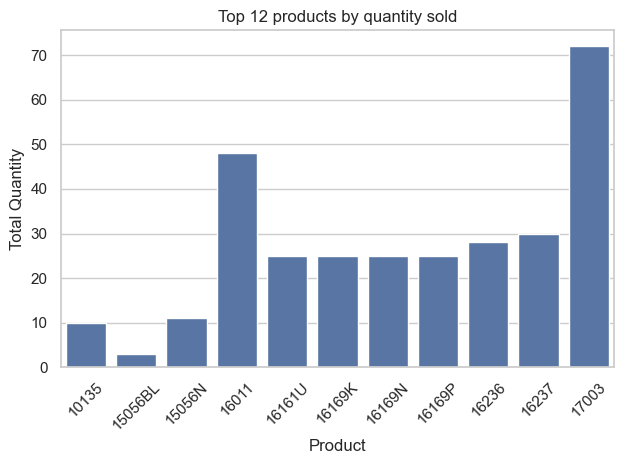

In [19]:
vz.plot_total_quantity_bar(conn)

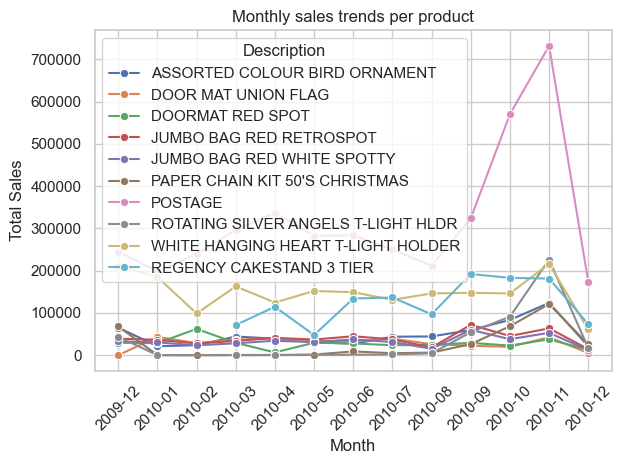

In [20]:
vz.plot_sales_trends_line(conn)

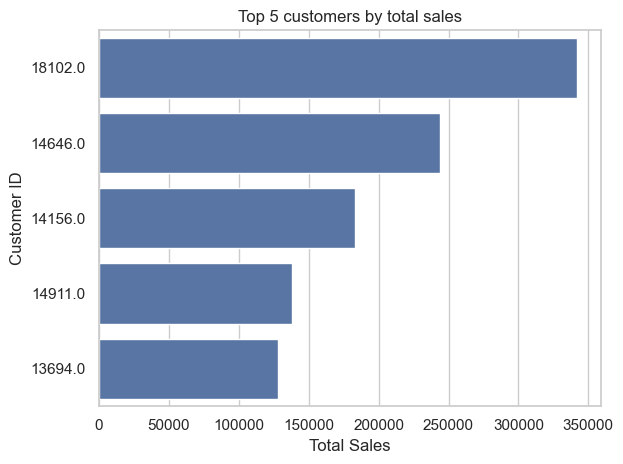

In [21]:
vz.plot_top_customers_barh(conn)

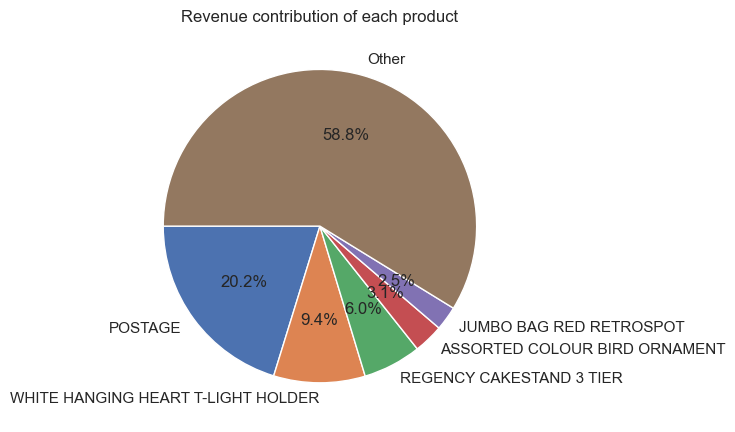

In [23]:
vz.plot_revenue_pie_chart(conn)